# TP Text Mining — Détection de Spam SMS

**Objectif :** Appliquer les techniques de text mining (Bag-of-Words, TF-IDF) et la régression logistique pour classifier des SMS en spam ou ham (non-spam).

---

## 1. Importation des bibliothèques

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


## 2. Chargement et exploration des données

In [55]:
spams = pd.read_table("data/SMSSpamCollection.txt", sep="\t", header=0)
print("Dimensions du dataset :", spams.shape)
print("\nAperçu des premières lignes :")
spams.head()

Dimensions du dataset : (5572, 2)

Aperçu des premières lignes :


,classe,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Distribution des classes

In [56]:
print("Distribution des classes :")
print(spams['classe'].value_counts())
print(f"\nProportion de spam : {spams['classe'].value_counts(normalize=True)['spam']:.2%}")

Distribution des classes :
classe
ham     4825
spam     747
Name: count, dtype: int64

Proportion de spam : 13.41%


Visualisation

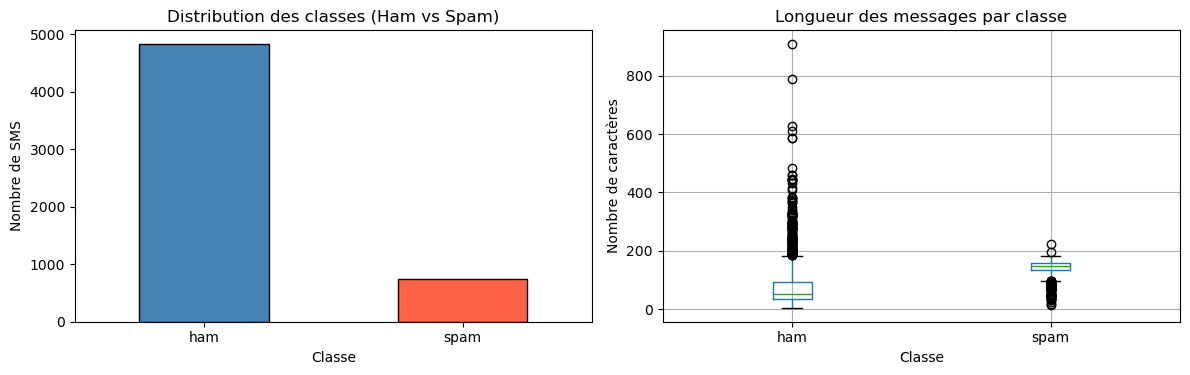


Observation : les spams sont généralement plus longs que les ham.


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

spams['classe'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribution des classes (Ham vs Spam)')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de SMS')
axes[0].tick_params(axis='x', rotation=0)

spams['longueur'] = spams['message'].apply(len)
spams.boxplot(column='longueur', by='classe', ax=axes[1])
axes[1].set_title('Longueur des messages par classe')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre de caractères')
plt.suptitle('')

plt.tight_layout()
plt.savefig('figs/distribution_classes.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nObservation : les spams sont généralement plus longs que les ham.")

## 3. Fonctions de prétraitement (nettoyage du corpus)

In [58]:
def clean_data(corpus_ensemble_doc):
    """
    Nettoie le corpus :
    - Mise en minuscules
    - Suppression de la ponctuation
    - Suppression des stopwords anglais
    """
    corpus = corpus_ensemble_doc.copy()  
    stopwords_anglais = stopwords.words('english')

    for i in range(len(corpus)):
        corpus[i] = corpus[i].lower()
        for c in string.punctuation:
            corpus[i] = corpus[i].replace(c, " ")
        mots = corpus[i].split()
        mots = [m for m in mots if m not in stopwords_anglais]
        corpus[i] = " ".join(mots)

    return corpus

print("Exemple de nettoyage :")
exemple = ["Free entry in 2 a wkly comp to win FA Cup final tkts!"]
print("Avant :", exemple[0])
print("Après :", clean_data(exemple)[0])

Exemple de nettoyage :
Avant : Free entry in 2 a wkly comp to win FA Cup final tkts!
Après : free entry 2 wkly comp win fa cup final tkts


## 4. Fonctions TF et TF-IDF manuelles

> Ces fonctions illustrent les formules vues en cours. Elles sont implémentées à titre pédagogique.

In [59]:
def tf(terme, corpus, numero_document):
    """
    TF = nombre d'occurrences du terme / nombre total de termes du document
    """
    nb_occurrences = corpus[numero_document].split().count(terme)
    nb_termes = len(corpus[numero_document].split())
    if nb_termes == 0:
        return 0
    return nb_occurrences / nb_termes


def tfidf(terme, corpus, numero_document):
    """
    TF-IDF = TF * log(1 + D / d_t)
    D = nombre total de documents, d_t = documents contenant le terme
    """
    D = len(corpus)
    d_t = sum(1 for doc in corpus if terme in doc.split())
    if d_t == 0:
        return 0
    tf_val = tf(terme, corpus, numero_document)
    return tf_val * np.log(1 + (D / d_t))


def cles_correspondante_a_valeur(valeur, dictionnaire):
    for cle, val in dictionnaire.items():
        if val == valeur:
            return cle
    return None


def matrice_sparse(dictionnaire, corpus_ensemble_documents):
    n_docs = len(corpus_ensemble_documents)
    n_termes = len(dictionnaire)
    M = np.zeros((n_docs, n_termes))
    for i in range(n_docs):
        for j in dictionnaire.values():
            terme = cles_correspondante_a_valeur(j, dictionnaire)
            M[i][j] = tfidf(terme, corpus_ensemble_documents, i)
    return M


def affiche(M):
    print(np.round(M, 2))




## 5. Application sur le dataset SMS Spam

### Préparation du jeu d'entraînement / test

In [60]:
spamsTrain, spamsTest = train_test_split(spams, train_size=0.7, random_state=1)

print(f"Taille du jeu d'entraînement : {len(spamsTrain)} SMS")
print(f"Taille du jeu de test        : {len(spamsTest)} SMS")
print(f"\nRépartition dans train :")
print(spamsTrain['classe'].value_counts())
print(f"\nRépartition dans test :")
print(spamsTest['classe'].value_counts())

Taille du jeu d'entraînement : 3900 SMS
Taille du jeu de test        : 1672 SMS

Répartition dans train :
classe
ham     3383
spam     517
Name: count, dtype: int64

Répartition dans test :
classe
ham     1442
spam     230
Name: count, dtype: int64


### Modèle 1 : CountVectorizer (fréquences brutes)

In [61]:
parseur1 = CountVectorizer()
XTrain1 = parseur1.fit_transform(spamsTrain["message"])
XTest1  = parseur1.transform(spamsTest["message"])

model1 = LogisticRegression(max_iter=1000)
model1.fit(XTrain1, spamsTrain["classe"])

score1_train = model1.score(XTrain1, spamsTrain["classe"])
score1_test  = model1.score(XTest1,  spamsTest["classe"])

print("Modèle 1 : CountVectorizer (fréquences brutes)")
print(f"Score sur le train : {score1_train:.4f}")
print(f"Score sur le test  : {score1_test:.4f}")
print(f"\nTaille du vocabulaire : {len(parseur1.get_feature_names_out())} termes")

Modèle 1 : CountVectorizer (fréquences brutes)
Score sur le train : 0.9979
Score sur le test  : 0.9815

Taille du vocabulaire : 7155 termes


### Modèle 2 : CountVectorizer binaire

In [62]:
parseur2 = CountVectorizer(binary=True)
XTrain2 = parseur2.fit_transform(spamsTrain["message"])
XTest2  = parseur2.transform(spamsTest["message"])

model2 = LogisticRegression(max_iter=1000)
model2.fit(XTrain2, spamsTrain["classe"])

score2_train = model2.score(XTrain2, spamsTrain["classe"])
score2_test  = model2.score(XTest2,  spamsTest["classe"])

print("Modèle 2 : CountVectorizer binaire")
print(f"Score sur le train : {score2_train:.4f}")
print(f"Score sur le test  : {score2_test:.4f}")

Modèle 2 : CountVectorizer binaire
Score sur le train : 0.9972
Score sur le test  : 0.9844


### Modèle 3 : CountVectorizer binaire + suppression des stop words

In [63]:
parseur3 = CountVectorizer(binary=True, stop_words='english')
XTrain3 = parseur3.fit_transform(spamsTrain["message"])
XTest3  = parseur3.transform(spamsTest["message"])

model3 = LogisticRegression(max_iter=1000)
model3.fit(XTrain3, spamsTrain["classe"])

score3_train = model3.score(XTrain3, spamsTrain["classe"])
score3_test  = model3.score(XTest3,  spamsTest["classe"])

print("Modèle 3 : CountVectorizer binaire + stop words")
print(f"Score sur le train : {score3_train:.4f}")
print(f"Score sur le test  : {score3_test:.4f}")
print(f"\nTaille du vocabulaire après stop words : {len(parseur3.get_feature_names_out())} termes")

Modèle 3 : CountVectorizer binaire + stop words
Score sur le train : 0.9959
Score sur le test  : 0.9749

Taille du vocabulaire après stop words : 6904 termes


### Modèle 4 : TF-IDF + stop words

In [64]:
parseur4 = TfidfVectorizer(stop_words='english')
XTrain4 = parseur4.fit_transform(spamsTrain["message"])
XTest4  = parseur4.transform(spamsTest["message"])

model4 = LogisticRegression(max_iter=1000)
model4.fit(XTrain4, spamsTrain["classe"])

score4_train = model4.score(XTrain4, spamsTrain["classe"])
score4_test  = model4.score(XTest4,  spamsTest["classe"])

print("Modèle 4 : TF-IDF + stop words")
print(f"Score sur le train : {score4_train:.4f}")
print(f"Score sur le test  : {score4_test:.4f}")

Modèle 4 : TF-IDF + stop words
Score sur le train : 0.9656
Score sur le test  : 0.9623


## 6. Comparaison des modèles et métriques détaillées

In [65]:
resultats = pd.DataFrame({
    'Modèle': [
        'CountVectorizer (fréq. brutes)',
        'CountVectorizer (binaire)',
        'CountVectorizer (binaire + stop words)',
        'TF-IDF (stop words)'
    ],
    'Score Train': [score1_train, score2_train, score3_train, score4_train],
    'Score Test':  [score1_test,  score2_test,  score3_test,  score4_test],
    'Écart (Overfitting)': [
        score1_train - score1_test,
        score2_train - score2_test,
        score3_train - score3_test,
        score4_train - score4_test
    ]
})

print("Récapitulatif des performances")
print(resultats.to_string(index=False, float_format='{:.4f}'.format))

Récapitulatif des performances
                                Modèle  Score Train  Score Test  Écart (Overfitting)
        CountVectorizer (fréq. brutes)       0.9979      0.9815               0.0165
             CountVectorizer (binaire)       0.9972      0.9844               0.0127
CountVectorizer (binaire + stop words)       0.9959      0.9749               0.0210
                   TF-IDF (stop words)       0.9656      0.9623               0.0033


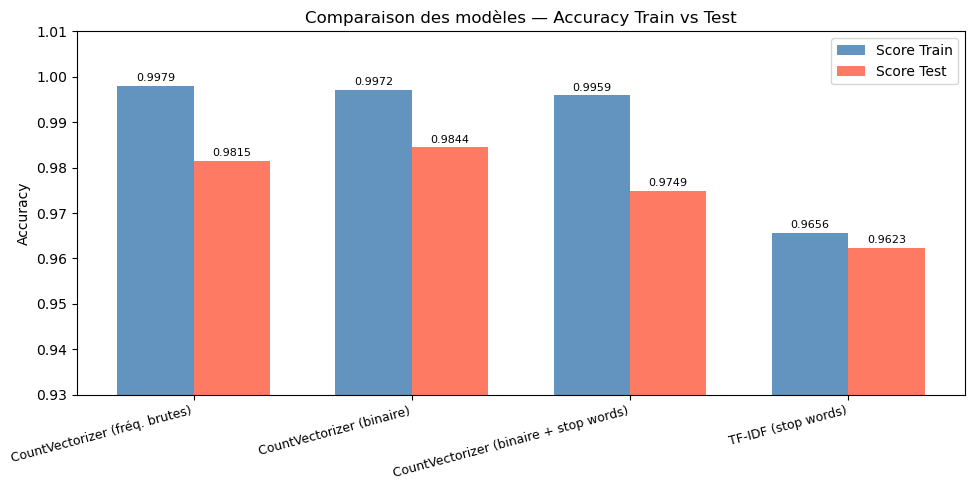

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(resultats))
width = 0.35

bars1 = ax.bar(x - width/2, resultats['Score Train'], width, label='Score Train', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, resultats['Score Test'],  width, label='Score Test',  color='tomato',    alpha=0.85)

ax.set_ylabel('Accuracy')
ax.set_title('Comparaison des modèles — Accuracy Train vs Test')
ax.set_xticks(x)
ax.set_xticklabels(resultats['Modèle'], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0.93, 1.01)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.4f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('figs/comparaison_modeles.png', dpi=100, bbox_inches='tight')
plt.show()

=== Rapport de classification — Modèle 1 (CountVectorizer fréquences brutes) ===
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1442
        spam       0.98      0.88      0.93       230

    accuracy                           0.98      1672
   macro avg       0.98      0.94      0.96      1672
weighted avg       0.98      0.98      0.98      1672



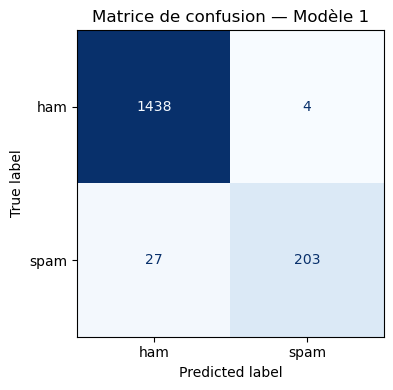

In [67]:
print("=== Rapport de classification — Modèle 1 (CountVectorizer fréquences brutes) ===")
y_pred1 = model1.predict(XTest1)
print(classification_report(spamsTest['classe'], y_pred1))

cm = confusion_matrix(spamsTest['classe'], y_pred1, labels=['ham','spam'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham','spam'])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de confusion — Modèle 1')
plt.tight_layout()
plt.savefig('figs/matrice_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

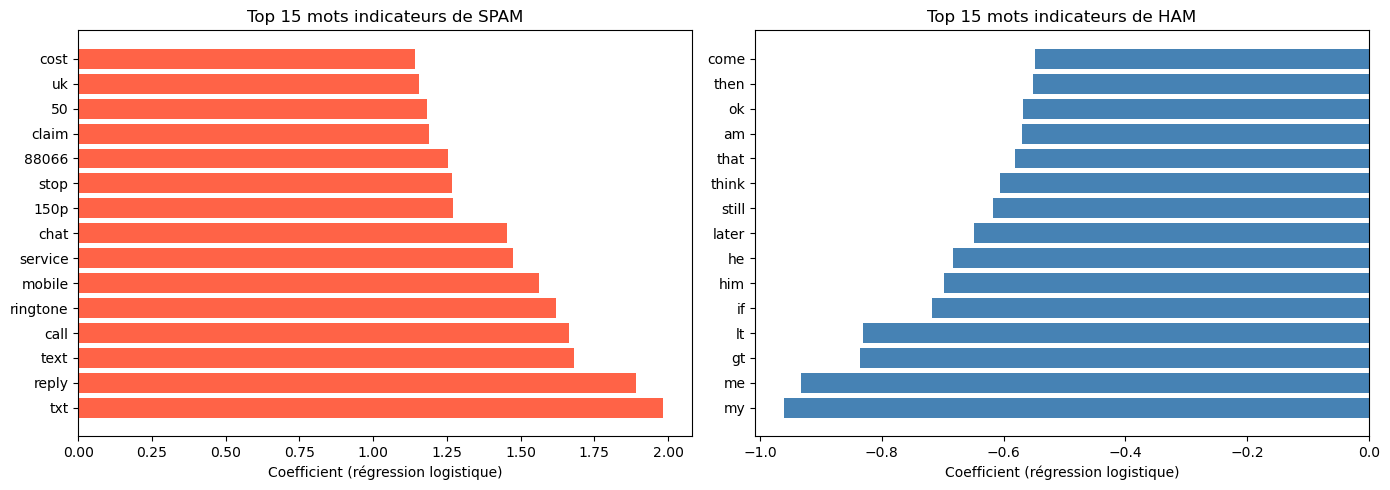

In [68]:
feature_names = parseur1.get_feature_names_out()
coefs = model1.coef_[0]

top_spam = np.argsort(coefs)[-15:][::-1]
top_ham  = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_spam], coefs[top_spam], color='tomato')
axes[0].set_title('Top 15 mots indicateurs de SPAM')
axes[0].set_xlabel('Coefficient (régression logistique)')

axes[1].barh(feature_names[top_ham], coefs[top_ham], color='steelblue')
axes[1].set_title('Top 15 mots indicateurs de HAM')
axes[1].set_xlabel('Coefficient (régression logistique)')

plt.tight_layout()
plt.savefig('figs/mots_discriminants.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Test sur de nouveaux messages

In [69]:
nouveaux_sms = [
    "Congratulations! You've won a FREE iPhone. Call now to claim your prize!",
    "Hey, are you free for lunch tomorrow?",
    "URGENT: Your account has been suspended. Click here to verify immediately.",
    "Can you pick up the kids from school today?",
    "Win 1000 cash prize! Text WIN to 85222 now!"
]

X_nouveaux = parseur1.transform(nouveaux_sms)
predictions = model1.predict(X_nouveaux)
probas = model1.predict_proba(X_nouveaux)

print("Prédictions sur de nouveaux SMS")
for sms, pred, proba in zip(nouveaux_sms, predictions, probas):
    classes = model1.classes_
    idx_spam = list(classes).index('spam')
    print(f"\nSMS        : {sms[:60]}..." if len(sms) > 60 else f"\nSMS        : {sms}")
    print(f"Prédiction : {pred.upper()} (confiance spam : {proba[idx_spam]:.2%})")

Prédictions sur de nouveaux SMS

SMS        : Congratulations! You've won a FREE iPhone. Call now to claim...
Prédiction : SPAM (confiance spam : 96.54%)

SMS        : Hey, are you free for lunch tomorrow?
Prédiction : HAM (confiance spam : 2.39%)

SMS        : URGENT: Your account has been suspended. Click here to verif...
Prédiction : HAM (confiance spam : 28.64%)

SMS        : Can you pick up the kids from school today?
Prédiction : HAM (confiance spam : 0.45%)

SMS        : Win 1000 cash prize! Text WIN to 85222 now!
Prédiction : SPAM (confiance spam : 95.68%)


## 8. Synthèse et conclusions

| Modèle | Score Train | Score Test | Overfitting |
|--------|------------|-----------|-------------|
| CountVectorizer (fréq. brutes) | 0.9979 | 0.9815 | Faible (0.0165) |
| CountVectorizer (binaire) | 0.9972 | **0.9844** | **Très faible (0.0127)** |
| Binaire + stop words | 0.9959 | 0.9749 | Modéré (0.0210) |
| TF-IDF + stop words | 0.9656 | 0.9623 | Minimal (0.0033) |

**Conclusions :**

- Le modèle **CountVectorizer binaire** offre le meilleur score sur le test (98.44%) avec le plus faible overfitting hors TF-IDF (1.27 pts). Cela suggère que c'est la *présence* d'un terme qui est le signal discriminant le plus fort — la répétition n'apporte pas d'information supplémentaire exploitable par la régression logistique.

- La suppression des stop words **dégrade les performances** (97.49%, soit −0.95 pt vs binaire), alors même que la réduction du vocabulaire est marginale (7155 → 6904 termes, soit seulement 251 termes supprimés). Cela indique que certains stop words (ex. *to*, *your*, *call*) ont une distribution différente entre spam et ham et constituent des signaux discriminants perdus lors de leur suppression.

- Le TF-IDF présente le **moins d'overfitting (0.0033)** mais les scores absolus les plus bas (96.23% en test). La pondération IDF pénalise les termes fréquents dans le corpus, ce qui réduit le poids de mots-clés spam très répandus comme *free*, *win* ou *call*, diminuant leur pouvoir discriminant.

- Le rapport de classification du Modèle 1 révèle un **rappel spam de seulement 88%** (précision : 98%), ce qui signifie que **12% des spams ne sont pas détectés** (faux négatifs). En contrepartie, presque aucun ham n'est classé à tort comme spam (rappel ham : 100%). Dans un contexte réel, on pourrait abaisser le seuil de décision pour augmenter le rappel spam au prix de quelques faux positifs supplémentaires.

- La régression logistique est très efficace sur ce type de données textuelles, avec des performances supérieures à **96% dans tous les cas**.